In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# In new notebook — load
import pickle
import os

# DATA_DIR = r"C:\Users\shaog\OneDrive\Documents\DSE3101\data"
# with open(os.path.join(DATA_DIR, "pt_ride_df.pkl"), "rb") as f:
#     pt_ride_df = pickle.load(f)

# DATA_DIR = r"C:\Users\wxcal\Desktop\Y3S2\DSE3101\data"
# with open(os.path.join(DATA_DIR, "pt_ride_df.pkl"), "rb") as f:
#     pt_ride_df = pickle.load(f)

DATA_DIR = r"C:\Users\Jeslyn\OneDrive\Documents\National University of Singapore (NUS)\Y3S2 (2026)\DSE3101\Project\data"
with open(os.path.join(DATA_DIR, "df2.pkl"), "rb") as f:
    pt_ride_df = pickle.load(f)

In [6]:
pt_ride_df.head()

,BUS_SVC_NUM,CRD_NUM,DEST_LOC_ID_NUM,ENTRY_DT,ENTRY_TM,EXIT_DT,EXIT_TM,ORIG_LOC_ID_NUM,RIDE_DISC_AMT,RIDE_DIST_KM_CNT,...,DEST_STATION_NAME,DEST_MRK_ID_NUM,DEST_LATITUDE,DEST_LONGITUDE,DEST_Travel_Type,ORIG_STATION_NAME,ORIG_MRK_ID_NUM,ORIG_LATITUDE,ORIG_LONGITUDE,ORIG_Travel_Type
0,NaN,9200002624150,402,2025-02-22,2025-02-22 12:37:05,2025-02-22,2025-02-22 12:37:29,403,0.0,1.4,...,Woodlands TEL,402.0,1.436058,103.787939,TRAIN,Woodlands South,403.0,1.427396,103.793264,TRAIN
1,187.0,240000373709,2753,2025-02-22,2025-02-22 10:05:07,2025-02-22,2025-02-22 10:09:32,2767,0.0,1.1,...,Opp Blk 628,2753.0,1.351755,103.750199,BUS,Blk 315,2767.0,1.360038,103.746242,BUS
2,168.0,9200002624150,4344,2025-02-22,2025-02-22 12:46:47,2025-02-22,2025-02-22 13:15:51,5060,0.0,13.3,...,Bef Seletar Camp G,4344.0,1.402222,103.871388,BUS,Woodlands Int B10,5060.0,1.437037,103.786132,BUS
3,NaN,240000373709,17,2025-02-22,2025-02-22 10:40:23,2025-02-22,2025-02-22 10:41:11,28,0.0,12.4,...,Redhill,17.0,1.289635,103.816741,TRAIN,Bukit Batok,28.0,1.349033,103.749567,TRAIN
4,NaN,9190001883020,41,2025-02-22,2025-02-22 10:30:17,2025-02-22,2025-02-22 10:39:53,42,0.0,2.4,...,Tampines NSEW,41.0,1.353302,103.945145,TRAIN,Pasir Ris,42.0,1.373043,103.949285,TRAIN


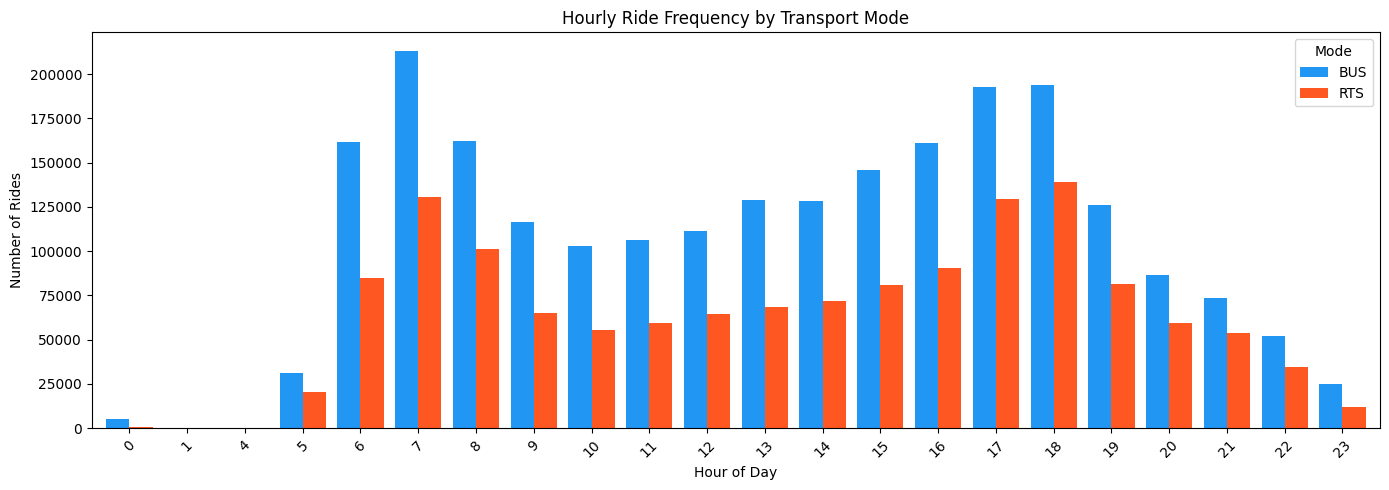

In [4]:
# Extract hour
pt_ride_df['HOUR'] = pt_ride_df['ENTRY_TM'].apply(lambda x: x.hour)
hourly_mode = (
    pt_ride_df.groupby(['HOUR', 'TRNSPT_MODE_DESC_TXT'])
    .size()
    .unstack(fill_value=0)
    .rename_axis(None, axis=1)
)

hourly_mode.plot(kind='bar', figsize=(14, 5), color=['#2196F3', '#FF5722'], width=0.8)
plt.title('Hourly Ride Frequency by Transport Mode')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45)
plt.legend(title='Mode')
plt.tight_layout()
plt.show()

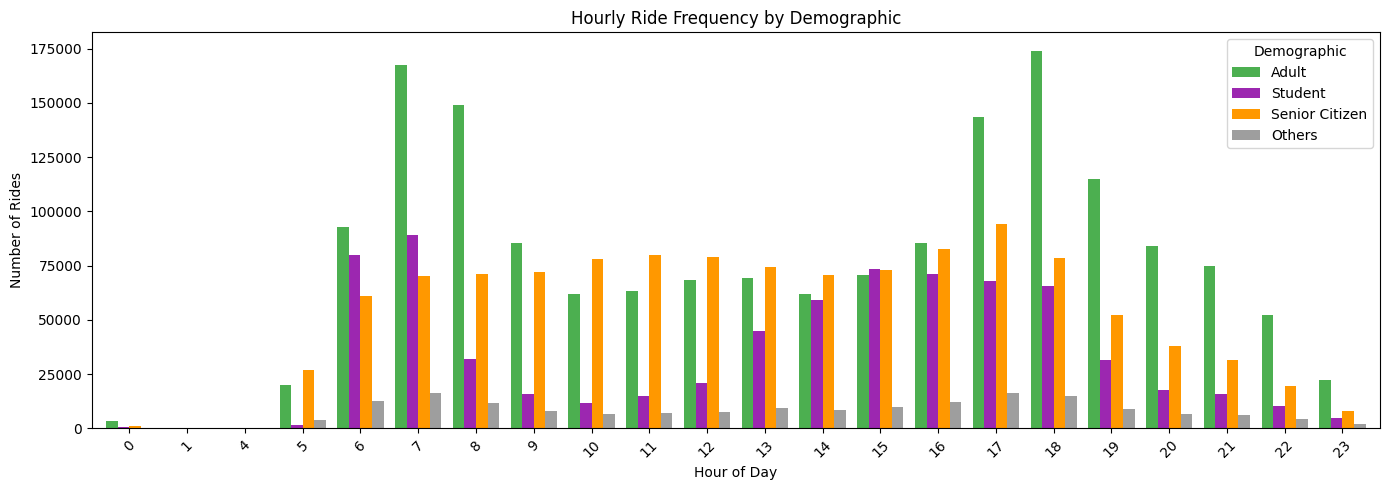

In [5]:
hourly_demo = (
    pt_ride_df.groupby(['HOUR', 'PATRON_CATG_DESC_TXT'])
    .size()
    .unstack(fill_value=0)
    .rename_axis(None, axis=1)
)

demo_grouped = pd.DataFrame({
    'Adult':          hourly_demo['Adult'],
    'Student':        hourly_demo['Student'],
    'Senior Citizen': hourly_demo['Senior Citizen'],
    'Others':         hourly_demo[['Child', 'PWD', 'Staff / Free Fare', 'WTCS']].sum(axis=1)
})

demo_grouped.plot(kind='bar', figsize=(14, 5), color=['#4CAF50', '#9C27B0', '#FF9800', '#9E9E9E'], width=0.8)
plt.title('Hourly Ride Frequency by Demographic')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45)
plt.legend(title='Demographic')
plt.tight_layout()
plt.show()